# Credit Risk EDA — Commerce Data

## Business Context
We're building a **proxy credit risk model** for Bati Bank using transaction data
from the Xente eCommerce platform. There is no direct "default" label — we'll
engineer one from behavioral patterns (RFM) in Task 4.

This notebook covers:
1. Data overview & structure
2. Summary statistics
3. Numerical & categorical distributions
4. Missing values & outlier detection
5. Temporal patterns & fraud distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="tab10")

df = pd.read_csv("../data/raw/alternate_data.csv", parse_dates=["TransactionStartTime"])
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [2]:
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nUnique customers: {df['CustomerId'].nunique()}")
print(f"Date range: {df['TransactionStartTime'].min()} → {df['TransactionStartTime'].max()}")

Shape: (95662, 16)

Data Types:
TransactionId                        object
BatchId                              object
AccountId                            object
SubscriptionId                       object
CustomerId                           object
CurrencyCode                         object
CountryCode                           int64
ProviderId                           object
ProductId                            object
ProductCategory                      object
ChannelId                            object
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[ns, UTC]
PricingStrategy                       int64
FraudResult                           int64
dtype: object

Unique customers: 3742
Date range: 2018-11-15 02:18:49+00:00 → 2019-02-13 10:01:28+00:00


## Summary Statistics
Quick look at central tendency and spread of numerical columns.

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
TransactionId,95662,95662,TransactionId_76871,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BatchId,95662,94809,BatchId_67019,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountId,95662,3633,AccountId_4841,30893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SubscriptionId,95662,3627,SubscriptionId_3829,32630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerId,95662,3742,CustomerId_7343,4091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CurrencyCode,95662,1,UGX,95662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryCode,95662.0,NaN,NaN,NaN,256.0,256.0,256.0,256.0,256.0,256.0,0.0
ProviderId,95662,6,ProviderId_4,38189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductId,95662,23,ProductId_6,32635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,95662,9,financial_services,45405,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("No missing values found.")
else:
    print(missing)
    missing.plot(kind="bar", title="Missing Values per Column")
    plt.tight_layout(); plt.show()

No missing values found.


## Numerical Feature Distributions (Transaction Level)
Raw transaction amounts before any aggregation. `Amount` can be negative
(refunds/credits back to customer). `Value` is always positive: the absolute amount.

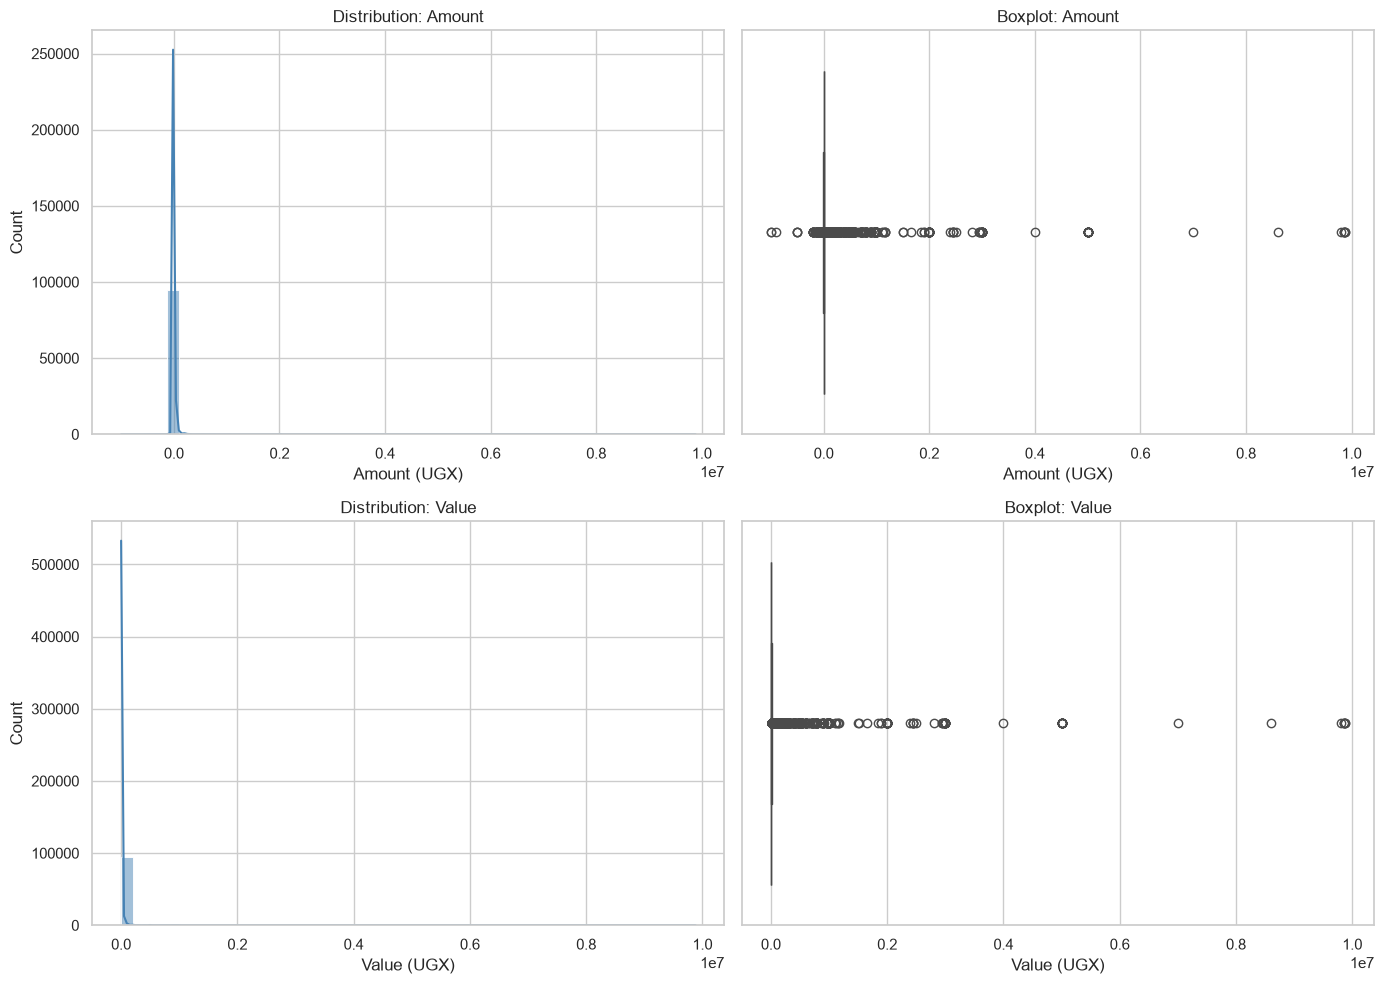

In [5]:
num_cols = ["Amount", "Value"]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="steelblue", bins=50)
    axes[i, 0].set_title(f"Distribution: {col}")
    axes[i, 0].set_xlabel(f"{col} (UGX)")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="steelblue")
    axes[i, 1].set_title(f"Boxplot: {col}")
    axes[i, 1].set_xlabel(f"{col} (UGX)")

plt.tight_layout()
plt.show()

## Categorical Feature Distributions
Top categories for `ProductCategory`, `ChannelId`, `ProviderId`, and `PricingStrategy`.

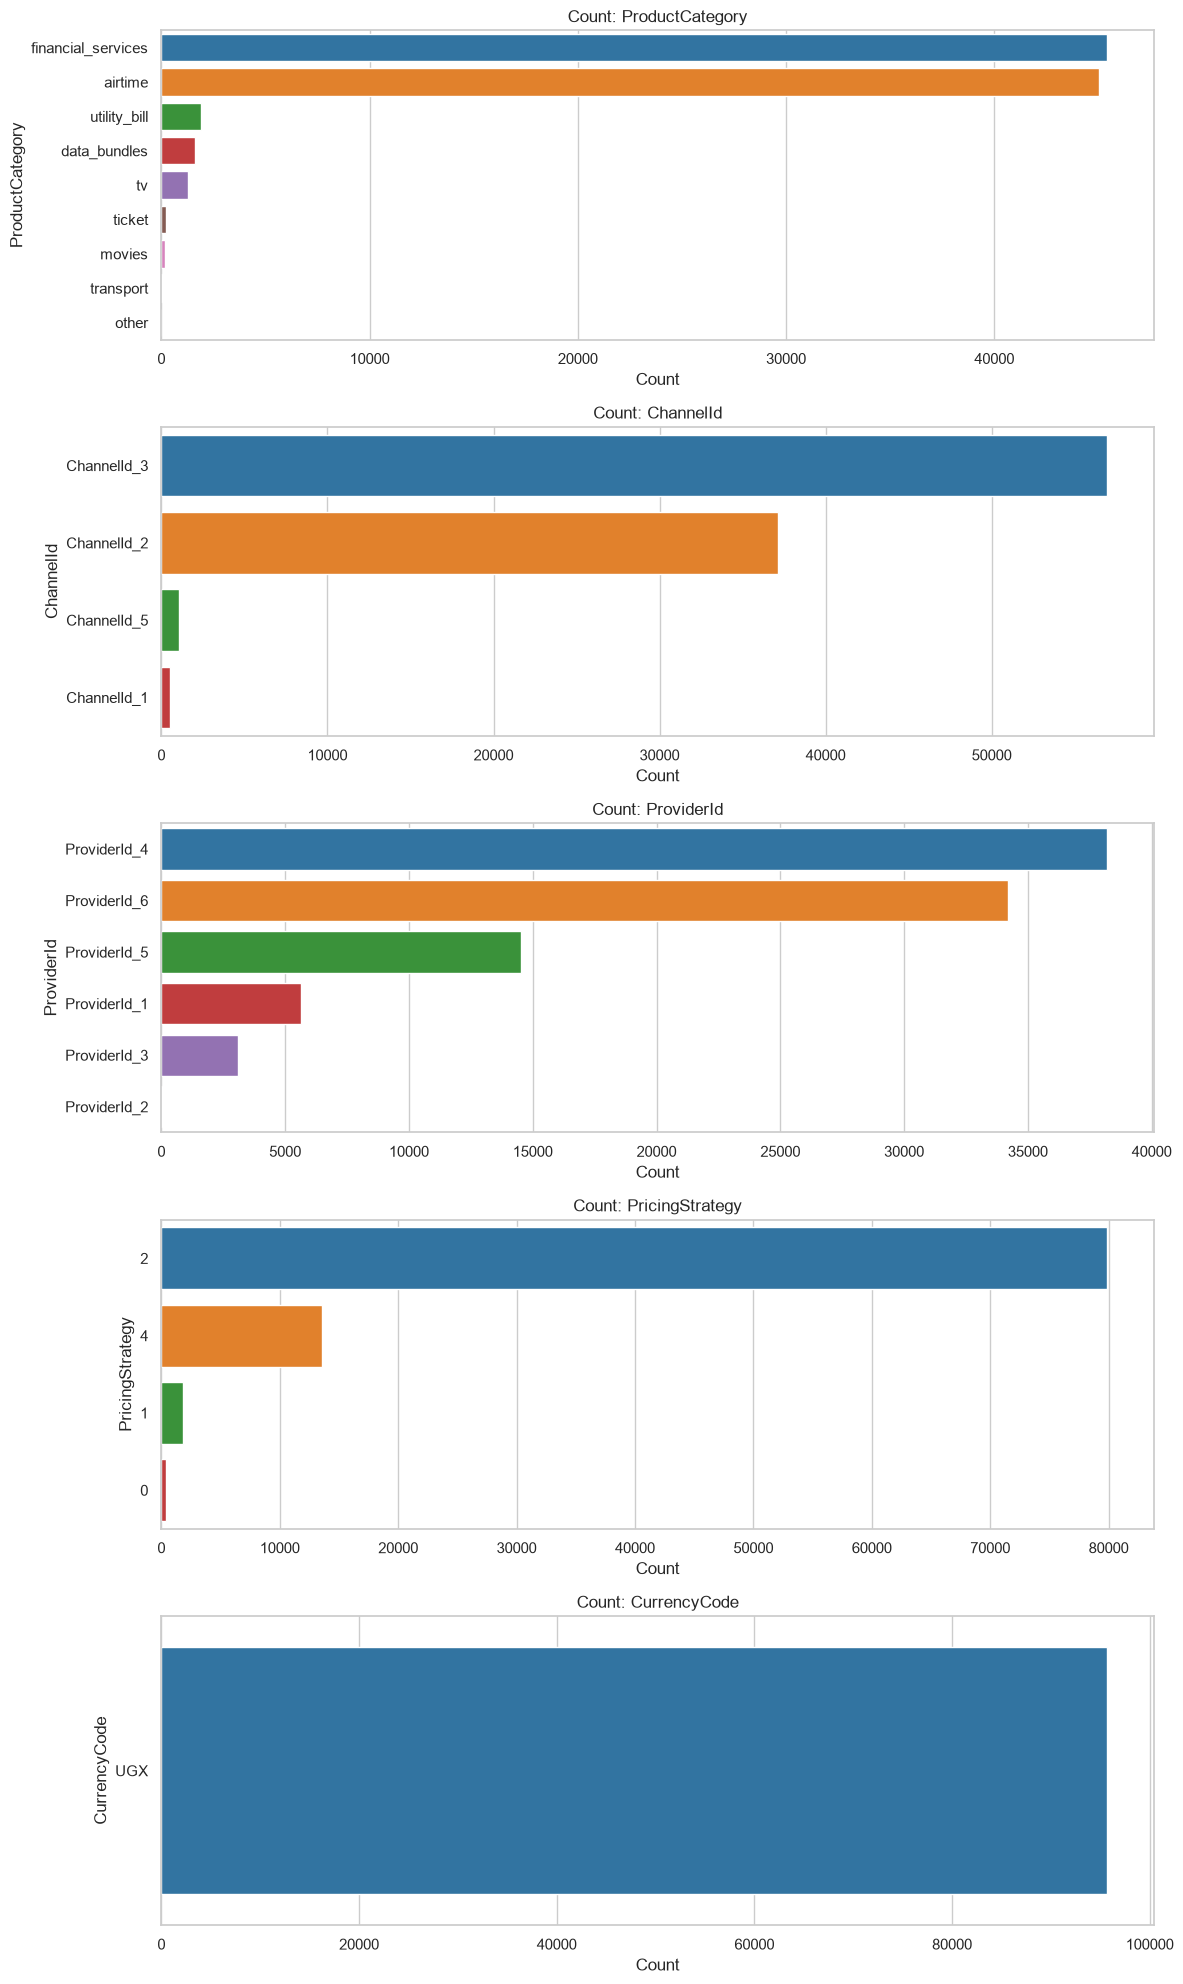

In [6]:
cat_cols = ["ProductCategory", "ChannelId", "ProviderId", "PricingStrategy", "CurrencyCode"]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 4 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="tab10")
    axes[i].set_title(f"Count: {col}")
    axes[i].set_xlabel("Count")

plt.tight_layout(); plt.show()

## Transaction Volume Over Time
Are there any seasonal or temporal spikes in transaction activity?

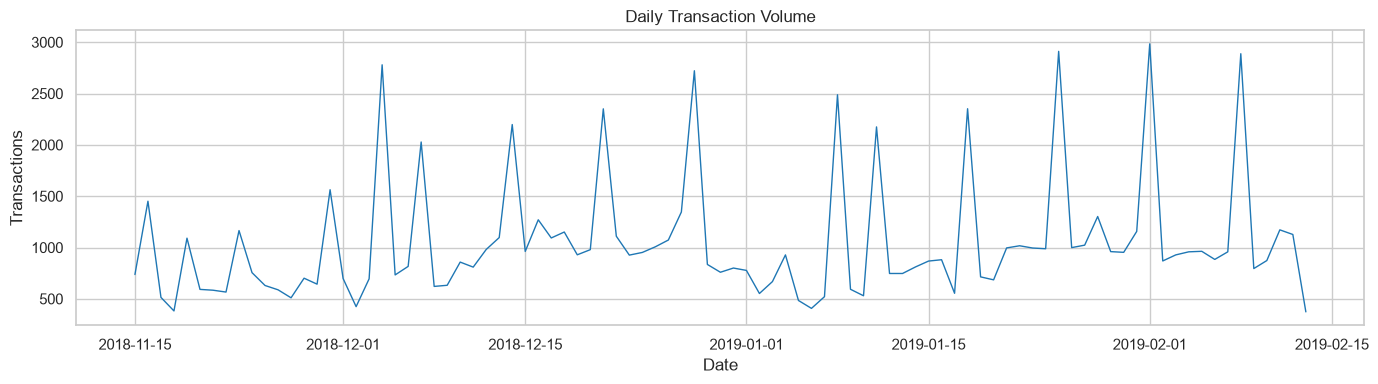

In [7]:
df["date"] = df["TransactionStartTime"].dt.date
daily = df.groupby("date")["TransactionId"].count().reset_index()
daily.columns = ["date", "count"]

plt.figure(figsize=(14, 4))
plt.plot(pd.to_datetime(daily["date"]), daily["count"], linewidth=1)
plt.title("Daily Transaction Volume")
plt.xlabel("Date"); plt.ylabel("Transactions")
plt.tight_layout(); plt.show()

## Transaction Hour & Day Patterns
When do customers transact most?

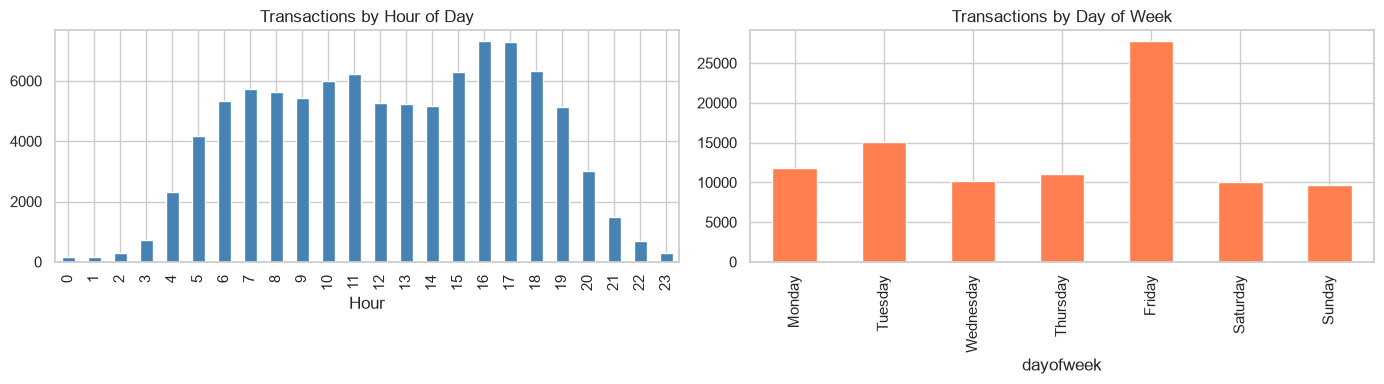

In [8]:
df["hour"] = df["TransactionStartTime"].dt.hour
df["dayofweek"] = df["TransactionStartTime"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Transactions by Hour of Day")
axes[0].set_xlabel("Hour")

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["dayofweek"].value_counts().reindex(dow_order).plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Transactions by Day of Week")

plt.tight_layout(); plt.show()

## Fraud Distribution
`FraudResult` is highly imbalanced — this is typical in fraud datasets and will
inform how we treat class imbalance in modeling.

FraudResult
0    95469
1      193
Name: count, dtype: int64

Fraud rate: 0.20%


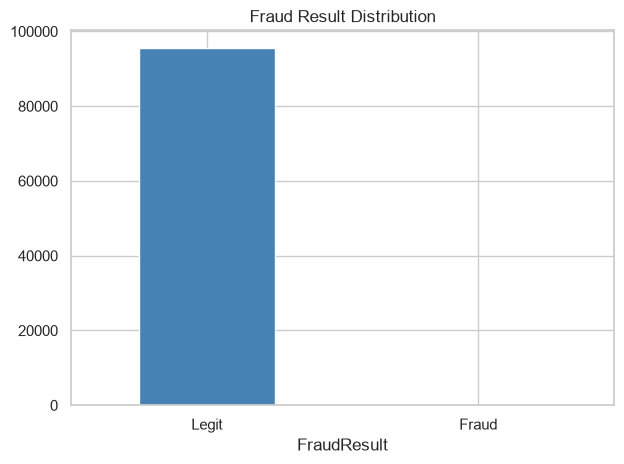

In [9]:
fraud_counts = df["FraudResult"].value_counts()
print(fraud_counts)
print(f"\nFraud rate: {fraud_counts[1] / len(df):.2%}")

fraud_counts.plot(kind="bar", title="Fraud Result Distribution", color=["steelblue","coral"])
plt.xticks([0, 1], ["Legit", "Fraud"], rotation=0)
plt.tight_layout(); plt.show()

## Key Insights

1. **Heavy skew in Amount/Value**: a small number of high-value transactions
   dominate; outlier capping will be needed before modeling.
2. **Temporal patterns**: transaction spikes at certain hours/days suggest
   behavioral features (hour, day-of-week) could be predictive.
3. **Fraud is rare (~<1%)**: severe class imbalance; model evaluation must use
   AUC-ROC and F1, not accuracy.
4. **`Value` is the absolute value of `Amount`**: expect near-perfect correlation
   between amount-based and value-based aggregates — likely redundant at the
   customer level, to confirm in Task 3/4.
5. **Customers vary widely in transaction count and recency of activity**: this
   motivates using RFM (Recency, Frequency, Monetary) as the basis for a proxy
   risk segmentation in Task 4.